# Federated Transfer Learning for Satellite Image Classification

This notebook implements **Federated Averaging (FedAvg)** on top of a ResNet-50 transfer learning pipeline for satellite image classification.

**Key idea:** Multiple simulated clients (geographic regions) collaboratively train only the FC classification head (~20K params) without sharing raw satellite imagery. The frozen ResNet-50 backbone acts as a shared feature extractor.

**Experiments:**
1. Centralized baseline (standard training)
2. Federated IID (5 clients, uniform data split)
3. Federated non-IID (Dirichlet α=0.5, heterogeneous data)
4. Comparison and communication cost analysis

---

### Setup
1. Go to **Runtime → Change runtime type** and select **T4 GPU**
2. Run all cells in order

## 1. Environment Setup & GPU Check

In [42]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms, models
from collections import OrderedDict, defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import shutil
import random
import zipfile

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # Optimize for fixed input sizes
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Go to Runtime \u2192 Change runtime type \u2192 T4 GPU")

PyTorch version : 2.9.0+cu126
Device          : cuda
GPU             : Tesla T4
GPU Memory      : 15.6 GB


## 2. Dataset Preparation

Download EuroSAT RGB and split into 80% train / 20% val (reuses the same pipeline from the centralized notebook).

In [43]:
# ── Download EuroSAT RGB ───────────────────────────────────────────
DATASET_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip"
DOWNLOAD_DIR = Path("Datasets")
ZIP_PATH = DOWNLOAD_DIR / "EuroSAT_RGB.zip"
SOURCE_DIR = DOWNLOAD_DIR / "EuroSAT_RGB"

if SOURCE_DIR.exists() and any(SOURCE_DIR.iterdir()):
    print(f"Dataset already exists at {SOURCE_DIR}, skipping download.")
else:
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    print("Downloading EuroSAT RGB dataset...")
    !wget -q --show-progress -O "{ZIP_PATH}" "{DATASET_URL}"
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DOWNLOAD_DIR)
    ZIP_PATH.unlink()
    print(f"Dataset extracted to {SOURCE_DIR}")

# Show class folders
class_dirs = sorted([d for d in SOURCE_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
total = 0
print(f"\nClasses found: {len(class_dirs)}")
for d in class_dirs:
    count = len(list(d.glob('*.jpg')))
    total += count
    print(f"  {d.name:30s} {count:5d} images")
print(f"{'Total':32s} {total:5d} images")

Dataset already exists at Datasets/EuroSAT_RGB, skipping download.

Classes found: 10
  AnnualCrop                      3000 images
  Forest                          3000 images
  HerbaceousVegetation            3000 images
  Highway                         2500 images
  Industrial                      2500 images
  Pasture                         2000 images
  PermanentCrop                   2500 images
  Residential                     3000 images
  River                           2500 images
  SeaLake                         3000 images
Total                            27000 images


In [44]:
# ── Train/Val Split ────────────────────────────────────────────────
OUTPUT_DIR = Path("satellite_data")
TRAIN_RATIO = 0.8
SEED = 42

def split_dataset(source_dir, output_dir, train_ratio, seed):
    random.seed(seed)
    class_dirs = sorted([d for d in source_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    total_train = total_val = 0
    for class_dir in class_dirs:
        images = sorted([f for f in class_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.tif')])
        random.shuffle(images)
        split_idx = int(len(images) * train_ratio)
        train_images, val_images = images[:split_idx], images[split_idx:]
        for split_name, split_imgs in [('train', train_images), ('val', val_images)]:
            split_dir = output_dir / split_name / class_dir.name
            split_dir.mkdir(parents=True, exist_ok=True)
            for img in split_imgs:
                shutil.copy2(img, split_dir / img.name)
        total_train += len(train_images)
        total_val += len(val_images)
        print(f"  {class_dir.name:30s}  train: {len(train_images):5d}  val: {len(val_images):5d}")
    print(f"\nTotal  train: {total_train}  val: {total_val}")

if OUTPUT_DIR.exists():
    print(f"satellite_data already exists, skipping split.")
else:
    split_dataset(SOURCE_DIR, OUTPUT_DIR, TRAIN_RATIO, SEED)
    print(f"Dataset prepared at: {OUTPUT_DIR.resolve()}")

satellite_data already exists, skipping split.


## 3. Core Functions

Define all functions needed for both centralized and federated training. These mirror `model.py`, `data_loader.py`, `fed_data.py`, `fed_client.py`, and `fed_server.py`.

In [45]:
# ── Data Loading ──────────────────────────────────────────────────
NUM_CLASSES = 10
DATA_DIR = "satellite_data"
BATCH_SIZE = 32
NUM_WORKERS = 2

def get_transforms():
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])
    return {'train': transform, 'val': transform}

def load_datasets(data_dir):
    data_path = Path(data_dir)
    t = get_transforms()
    return {
        'train': datasets.ImageFolder(root=data_path / 'train', transform=t['train']),
        'val': datasets.ImageFolder(root=data_path / 'val', transform=t['val'])
    }

def create_dataloaders(datasets_dict, batch_size=32, num_workers=2):
    return {
        'train': DataLoader(datasets_dict['train'], batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True),
        'val': DataLoader(datasets_dict['val'], batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
    }

# Load datasets
datasets_dict = load_datasets(DATA_DIR)
train_dataset = datasets_dict['train']
class_names = train_dataset.classes
val_loader = create_dataloaders(datasets_dict, BATCH_SIZE, NUM_WORKERS)['val']

print(f"Training samples  : {len(train_dataset)}")
print(f"Validation samples: {len(datasets_dict['val'])}")
print(f"Classes           : {class_names}")

Training samples  : 21600
Validation samples: 5400
Classes           : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [46]:
# ── Model ─────────────────────────────────────────────────────────
NUM_CLASSES = 10

def create_model(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


class FCClassifier(nn.Module):
    """Lightweight FC-only classifier for cached backbone features."""
    def __init__(self, in_features=2048, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)
    def forward(self, x):
        return self.fc(x)


@torch.no_grad()
def extract_features(dataloader, device):
    """Extract 2048-dim features from frozen ResNet-50 backbone (one-time)."""
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    backbone.fc = nn.Identity()
    backbone = backbone.to(device).eval()
    use_amp = device.type == "cuda"
    all_features, all_labels = [], []
    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            features = backbone(images)
        all_features.append(features.float().cpu())
        all_labels.append(labels)
    del backbone
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return torch.cat(all_features), torch.cat(all_labels)


def train_fc_epoch(fc_model, dataloader, optimizer, criterion, device):
    """Train FC classifier on cached features for one epoch."""
    fc_model.train()
    running_loss = correct = total = 0
    for features, labels in dataloader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = fc_model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return {"loss": running_loss / total, "accuracy": 100.0 * correct / total}


def validate_fc(fc_model, dataloader, criterion, device):
    """Validate FC classifier on cached features."""
    fc_model.eval()
    running_loss = correct = total = 0
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = fc_model(features)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * features.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return {"loss": running_loss / total, "accuracy": 100.0 * correct / total}


# Verify model
test_model = create_model()
trainable = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in test_model.parameters() if not p.requires_grad)
print(f"Trainable params : {trainable:,} (FC layer only)")
print(f"Frozen params    : {frozen:,} (ResNet-50 backbone)")
del test_model

Trainable params : 20,490 (FC layer only)
Frozen params    : 23,508,032 (ResNet-50 backbone)


In [47]:
# ── Data Partitioning Functions ───────────────────────────────────

def _get_targets(dataset):
    if hasattr(dataset, 'targets'):
        return np.array(dataset.targets)
    return np.array([y for _, y in dataset])

def partition_iid(dataset, num_clients, seed=42):
    """Random equal split — each client gets ~uniform class distribution."""
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(dataset))
    shards = np.array_split(indices, num_clients)
    return {i: shard.tolist() for i, shard in enumerate(shards)}

def partition_non_iid_dirichlet(dataset, num_clients, alpha=0.5, seed=42):
    """Dirichlet-based non-IID split. Lower alpha = more heterogeneous."""
    rng = np.random.default_rng(seed)
    targets = _get_targets(dataset)
    num_classes = len(np.unique(targets))
    class_indices = defaultdict(list)
    for idx, label in enumerate(targets):
        class_indices[label].append(idx)
    client_indices = {i: [] for i in range(num_clients)}
    for c in range(num_classes):
        indices_c = np.array(class_indices[c])
        rng.shuffle(indices_c)
        proportions = rng.dirichlet(np.repeat(alpha, num_clients))
        counts = (proportions * len(indices_c)).astype(int)
        counts[np.argmax(proportions)] += len(indices_c) - counts.sum()
        start = 0
        for i in range(num_clients):
            client_indices[i].extend(indices_c[start:start + counts[i]].tolist())
            start += counts[i]
    return client_indices

def create_client_feature_dataloaders(features, labels, client_indices, batch_size=512):
    """Create DataLoaders from cached feature vectors for each client."""
    client_loaders = {}
    for cid, indices in client_indices.items():
        idx = torch.tensor(indices, dtype=torch.long)
        ds = TensorDataset(features[idx], labels[idx])
        client_loaders[cid] = DataLoader(
            ds, batch_size=batch_size, shuffle=True, pin_memory=True,
        )
    return client_loaders

def print_partition_stats(dataset, client_indices, class_names=None):
    targets = _get_targets(dataset)
    num_classes = len(np.unique(targets))
    if class_names is None:
        class_names = [str(c) for c in range(num_classes)]
    print(f"{'Client':<8}", end="")
    for name in class_names:
        print(f"{name[:8]:<10}", end="")
    print(f"{'Total':<8}")
    print("-" * (8 + 10 * num_classes + 8))
    for cid in sorted(client_indices.keys()):
        labels = targets[client_indices[cid]]
        counts = np.bincount(labels, minlength=num_classes)
        print(f"{cid:<8}", end="")
        for c in counts:
            print(f"{c:<10}", end="")
        print(f"{len(client_indices[cid]):<8}")

print("Partitioning functions defined.")

Partitioning functions defined.


In [48]:
# ── Federated Client (Optimized — FC only) ───────────────────────

class FederatedClient:
    def __init__(self, client_id, dataloader, device, num_classes=10):
        self.client_id = client_id
        self.dataloader = dataloader
        self.device = device
        self.model = FCClassifier(in_features=2048, num_classes=num_classes).to(device)
        self.num_samples = len(dataloader.dataset)

    def get_fc_params(self):
        return OrderedDict({
            "fc.weight": self.model.fc.weight.data.clone().cpu(),
            "fc.bias": self.model.fc.bias.data.clone().cpu(),
        })

    def set_fc_params(self, fc_state):
        self.model.fc.weight.data.copy_(fc_state["fc.weight"].to(self.device))
        self.model.fc.bias.data.copy_(fc_state["fc.bias"].to(self.device))

    def local_train(self, global_fc_params, local_epochs=5, lr=1e-3):
        self.set_fc_params(global_fc_params)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()
        epoch_metrics = []
        for _ in range(local_epochs):
            metrics = train_fc_epoch(self.model, self.dataloader, optimizer, criterion, self.device)
            epoch_metrics.append(metrics)
        return {
            "fc_params": self.get_fc_params(),
            "num_samples": self.num_samples,
            "metrics": epoch_metrics,
        }

# ── Federated Server (Optimized — FC only) ───────────────────────

class FederatedServer:
    def __init__(self, num_classes=10, device=None):
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device
        self.num_classes = num_classes
        self.model = FCClassifier(in_features=2048, num_classes=num_classes).to(device)

    def get_global_fc_params(self):
        return OrderedDict({
            "fc.weight": self.model.fc.weight.data.clone().cpu(),
            "fc.bias": self.model.fc.bias.data.clone().cpu(),
        })

    def aggregate(self, client_updates):
        total_samples = sum(u["num_samples"] for u in client_updates)
        agg_params = OrderedDict()
        for key in client_updates[0]["fc_params"]:
            agg_params[key] = torch.zeros_like(client_updates[0]["fc_params"][key])
        for update in client_updates:
            weight = update["num_samples"] / total_samples
            for key in agg_params:
                agg_params[key] += weight * update["fc_params"][key]
        self.model.fc.weight.data.copy_(agg_params["fc.weight"].to(self.device))
        self.model.fc.bias.data.copy_(agg_params["fc.bias"].to(self.device))
        return agg_params

    def evaluate(self, val_loader):
        criterion = nn.CrossEntropyLoss()
        return validate_fc(self.model, val_loader, criterion, self.device)

print("FederatedClient and FederatedServer defined (optimized).")

FederatedClient and FederatedServer defined (optimized).


In [49]:
# ── Federated Training Orchestration (Optimized) ─────────────────

def run_federated(num_clients=5, num_rounds=20, local_epochs=5,
                  partition="iid", alpha=0.5, batch_size=512, lr=1e-3,
                  num_classes=10):
    """Full FedAvg loop using cached backbone features."""
    print(f"\n{'='*60}")
    print(f"FEDERATED TRAINING \u2014 {partition.upper()} partition")
    print(f"{'='*60}")
    print(f"Clients: {num_clients} | Rounds: {num_rounds} | "
          f"Local epochs: {local_epochs} | LR: {lr}")
    print(f"Device: {device}")

    # Partition data
    if partition == "iid":
        client_indices = partition_iid(train_dataset, num_clients)
    elif partition == "dirichlet":
        client_indices = partition_non_iid_dirichlet(train_dataset, num_clients, alpha=alpha)
    else:
        raise ValueError(f"Unknown partition: {partition}")

    print(f"\nData partition ({partition}):")
    print_partition_stats(train_dataset, client_indices, class_names)

    # Create feature-based client dataloaders (no CNN needed!)
    client_loaders = create_client_feature_dataloaders(
        train_features, train_labels, client_indices, batch_size=batch_size
    )
    clients = {cid: FederatedClient(cid, loader, device, num_classes)
               for cid, loader in client_loaders.items()}
    server = FederatedServer(num_classes=num_classes, device=device)

    history = {
        "global_val_acc": [], "global_val_loss": [],
        "client_metrics": {cid: [] for cid in clients},
    }

    for rnd in range(1, num_rounds + 1):
        round_start = time.time()
        global_fc = server.get_global_fc_params()

        client_updates = []
        for cid, client in clients.items():
            result = client.local_train(global_fc, local_epochs=local_epochs, lr=lr)
            client_updates.append(result)
            history["client_metrics"][cid].append(result["metrics"][-1])

        server.aggregate(client_updates)
        val_m = server.evaluate(val_feature_loader)
        history["global_val_acc"].append(val_m["accuracy"])
        history["global_val_loss"].append(val_m["loss"])

        client_accs = [u["metrics"][-1]["accuracy"] for u in client_updates]
        elapsed = time.time() - round_start
        print(f"Round {rnd:3d}/{num_rounds} | "
              f"Val Acc: {val_m['accuracy']:.2f}% | "
              f"Val Loss: {val_m['loss']:.4f} | "
              f"Client Accs: [{', '.join(f'{a:.1f}' for a in client_accs)}] | "
              f"Time: {elapsed:.1f}s")

    history["client_indices"] = client_indices
    history["config"] = {
        "num_clients": num_clients, "num_rounds": num_rounds,
        "local_epochs": local_epochs, "partition": partition,
        "alpha": alpha, "lr": lr, "batch_size": batch_size,
    }
    print(f"\nFinal global val accuracy: {history['global_val_acc'][-1]:.2f}%")
    return history, server


def run_centralized_baseline(num_epochs=20, batch_size=512, lr=1e-3):
    """Centralized training using cached features."""
    print(f"\n{'='*60}")
    print("CENTRALIZED BASELINE TRAINING")
    print(f"{'='*60}")
    print(f"Epochs: {num_epochs} | Batch size: {batch_size} | LR: {lr}")

    _train_loader = DataLoader(TensorDataset(train_features, train_labels),
                                batch_size=batch_size, shuffle=True, pin_memory=True)
    model = FCClassifier(in_features=2048).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_acc": [], "train_loss": [], "val_acc": [], "val_loss": []}
    for epoch in range(1, num_epochs + 1):
        t_m = train_fc_epoch(model, _train_loader, optimizer, criterion, device)
        v_m = validate_fc(model, val_feature_loader, criterion, device)
        history["train_acc"].append(t_m["accuracy"])
        history["train_loss"].append(t_m["loss"])
        history["val_acc"].append(v_m["accuracy"])
        history["val_loss"].append(v_m["loss"])
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Acc: {t_m['accuracy']:.2f}% | "
              f"Val Acc: {v_m['accuracy']:.2f}% | "
              f"Val Loss: {v_m['loss']:.4f}")

    print(f"\nBest centralized val accuracy: {max(history['val_acc']):.2f}%")
    return history, model

print("Orchestration functions defined (optimized).")

Orchestration functions defined (optimized).


## 4. Extract Backbone Features (One-Time)

Extract 2048-dim feature vectors from the frozen ResNet-50 backbone for all train and val images. This is done **once** and cached in memory — all subsequent training (centralized and federated) operates on these lightweight feature vectors instead of raw images.

In [50]:
# Extract features from frozen ResNet-50 backbone (runs once, ~1-2 min on T4)
print("Extracting training features...")
train_img_loader = DataLoader(train_dataset, batch_size=128, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
train_features, train_labels = extract_features(train_img_loader, device)
print(f"  Train features: {train_features.shape}  (labels: {train_labels.shape})")

print("Extracting validation features...")
val_img_loader = DataLoader(datasets_dict['val'], batch_size=128, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_features, val_labels = extract_features(val_img_loader, device)
print(f"  Val features:   {val_features.shape}  (labels: {val_labels.shape})")

# Create a DataLoader for cached val features (used by server.evaluate)
val_feature_loader = DataLoader(
    TensorDataset(val_features, val_labels),
    batch_size=512, shuffle=False, pin_memory=True
)
print(f"\nFeature extraction complete. All training will use cached 2048-dim vectors.")

Extracting training features...
  Train features: torch.Size([21600, 2048])  (labels: torch.Size([21600]))
Extracting validation features...
  Val features:   torch.Size([5400, 2048])  (labels: torch.Size([5400]))

Feature extraction complete. All training will use cached 2048-dim vectors.


## 5. Run Experiments

### 5a. Centralized Baseline

In [51]:
centralized_history, centralized_model = run_centralized_baseline(
    num_epochs=20, batch_size=512, lr=1e-3
)


CENTRALIZED BASELINE TRAINING
Epochs: 20 | Batch size: 512 | LR: 0.001
Epoch   1/20 | Train Acc: 78.98% | Val Acc: 89.65% | Val Loss: 0.4265
Epoch   2/20 | Train Acc: 90.77% | Val Acc: 91.76% | Val Loss: 0.3028
Epoch   3/20 | Train Acc: 92.23% | Val Acc: 92.69% | Val Loss: 0.2539
Epoch   4/20 | Train Acc: 93.12% | Val Acc: 92.94% | Val Loss: 0.2280
Epoch   5/20 | Train Acc: 93.62% | Val Acc: 93.41% | Val Loss: 0.2125
Epoch   6/20 | Train Acc: 94.04% | Val Acc: 94.04% | Val Loss: 0.1955
Epoch   7/20 | Train Acc: 94.38% | Val Acc: 94.15% | Val Loss: 0.1864
Epoch   8/20 | Train Acc: 94.70% | Val Acc: 94.50% | Val Loss: 0.1788
Epoch   9/20 | Train Acc: 95.00% | Val Acc: 94.70% | Val Loss: 0.1713
Epoch  10/20 | Train Acc: 95.33% | Val Acc: 94.78% | Val Loss: 0.1662
Epoch  11/20 | Train Acc: 95.44% | Val Acc: 94.78% | Val Loss: 0.1618
Epoch  12/20 | Train Acc: 95.63% | Val Acc: 94.96% | Val Loss: 0.1593
Epoch  13/20 | Train Acc: 95.74% | Val Acc: 95.17% | Val Loss: 0.1543
Epoch  14/20 | Tra

### 5b. Federated IID

In [52]:
fed_iid_history, fed_iid_server = run_federated(
    num_clients=5,
    num_rounds=20,
    local_epochs=5,
    partition="iid",
    batch_size=512,
    lr=1e-3,
)


FEDERATED TRAINING — IID partition
Clients: 5 | Rounds: 20 | Local epochs: 5 | LR: 0.001
Device: cuda

Data partition (iid):
Client  AnnualCr  Forest    Herbaceo  Highway   Industri  Pasture   Permanen  Resident  River     SeaLake   Total   
--------------------------------------------------------------------------------------------------------------------
0       466       473       457       391       417       321       423       497       393       482       4320    
1       473       510       465       389       407       336       386       455       422       477       4320    
2       499       486       476       426       396       307       390       475       371       494       4320    
3       497       452       512       385       399       359       382       474       390       470       4320    
4       465       479       490       409       381       277       419       499       424       477       4320    
Round   1/20 | Val Acc: 89.78% | Val Loss: 0.4177 | Cli

### 5c. Federated Non-IID (Dirichlet α=0.5)

In [53]:
fed_noniid_history, fed_noniid_server = run_federated(
    num_clients=5,
    num_rounds=20,
    local_epochs=5,
    partition="dirichlet",
    alpha=0.5,
    batch_size=512,
    lr=1e-3,
)


FEDERATED TRAINING — DIRICHLET partition
Clients: 5 | Rounds: 20 | Local epochs: 5 | LR: 0.001
Device: cuda

Data partition (dirichlet):
Client  AnnualCr  Forest    Herbaceo  Highway   Industri  Pasture   Permanen  Resident  River     SeaLake   Total   
--------------------------------------------------------------------------------------------------------------------
0       1646      115       96        85        0         255       493       138       1024      522       4374    
1       326       614       112       1061      576       1         557       767       38        21        4073    
2       78        154       1345      155       190       1         107       402       119       884       3435    
3       185       457       777       2         34        1324      26        983       165       751       4704    
4       165       1060      70        697       1200      19        817       110       654       222       5014    
Round   1/20 | Val Acc: 73.54% | Val Loss: 

## 6. Per-Client Analysis & Class Distribution Visualizations

IID Partition:


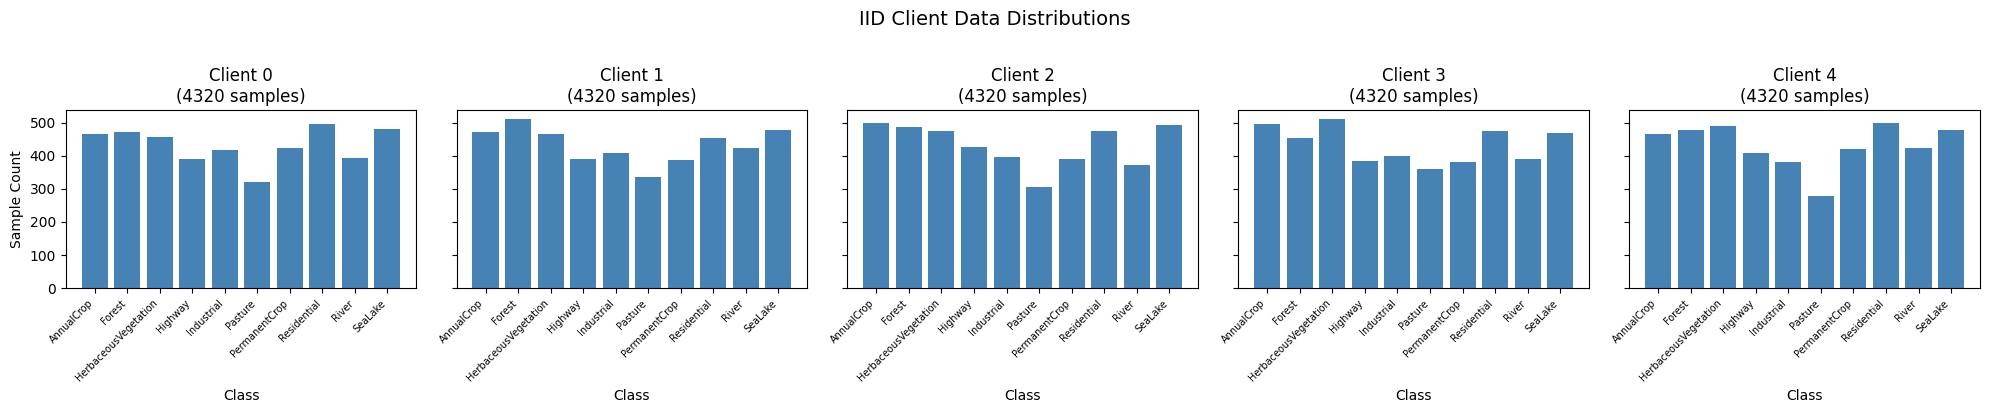


Non-IID (Dirichlet α=0.5) Partition:


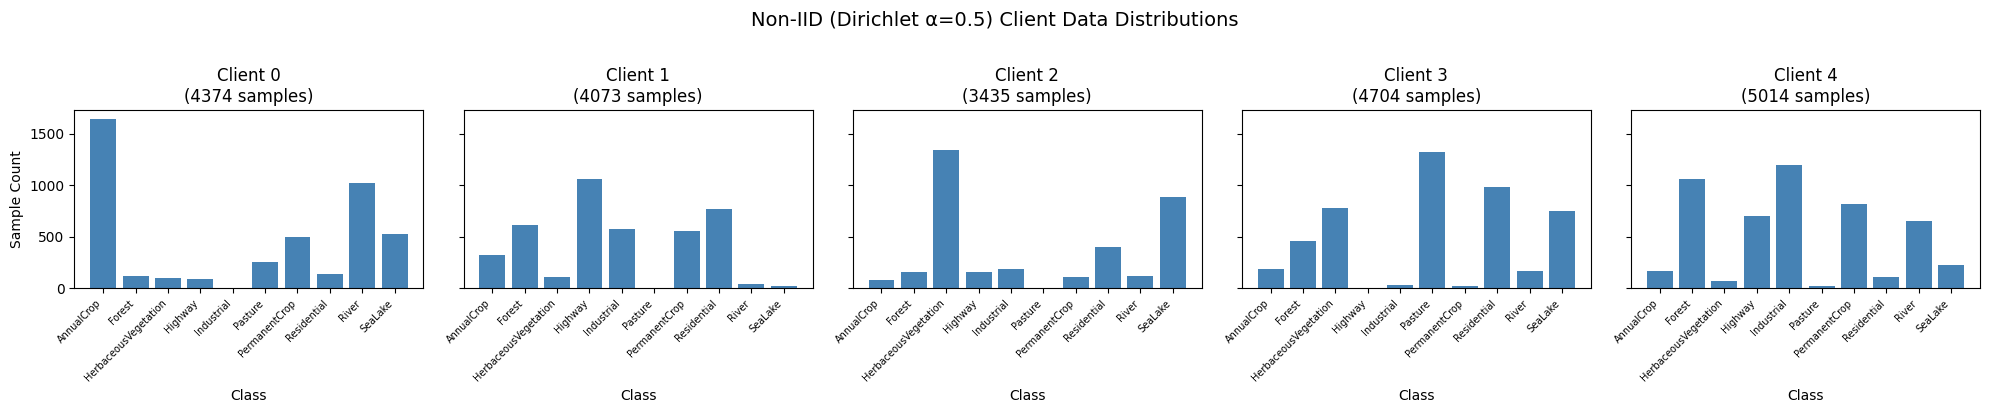

In [54]:
def plot_client_class_distribution(dataset, client_indices, class_names, title=""):
    """Bar chart of per-client class distributions."""
    targets = _get_targets(dataset)
    num_classes = len(np.unique(targets))
    num_clients = len(client_indices)
    fig, axes = plt.subplots(1, num_clients, figsize=(4 * num_clients, 4), sharey=True)
    if num_clients == 1:
        axes = [axes]
    for ax, (cid, indices) in zip(axes, sorted(client_indices.items())):
        labels = targets[indices]
        counts = np.bincount(labels, minlength=num_classes)
        ax.bar(range(num_classes), counts, color='steelblue')
        ax.set_title(f"Client {cid}\n({len(indices)} samples)")
        ax.set_xlabel("Class")
        ax.set_xticks(range(num_classes))
        ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    axes[0].set_ylabel("Sample Count")
    plt.suptitle(title if title else "Client Data Distributions", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# IID distribution
print("IID Partition:")
plot_client_class_distribution(train_dataset, fed_iid_history["client_indices"],
                                class_names, title="IID Client Data Distributions")

# Non-IID distribution
print("\nNon-IID (Dirichlet \u03b1=0.5) Partition:")
plot_client_class_distribution(train_dataset, fed_noniid_history["client_indices"],
                                class_names, title="Non-IID (Dirichlet \u03b1=0.5) Client Data Distributions")

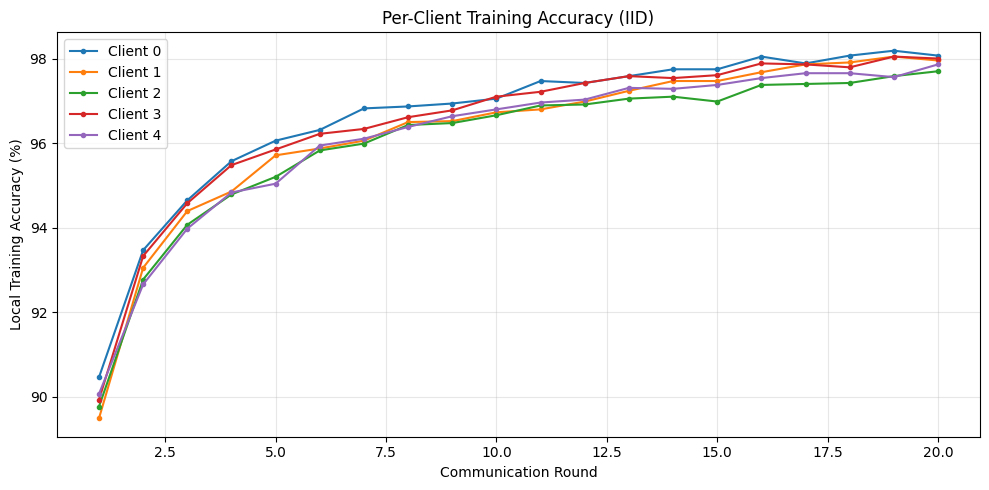

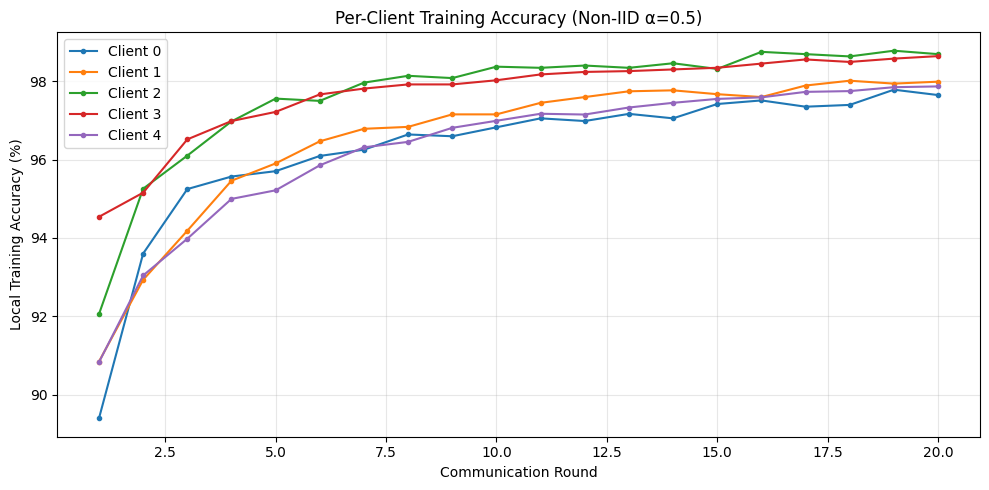

In [55]:
def plot_client_curves(history, title="Per-Client Training Accuracy"):
    """Plot per-client training accuracy across rounds."""
    plt.figure(figsize=(10, 5))
    for cid, metrics_list in history["client_metrics"].items():
        accs = [m["accuracy"] for m in metrics_list]
        rounds = range(1, len(accs) + 1)
        plt.plot(rounds, accs, "-o", markersize=3, label=f"Client {cid}")
    plt.xlabel("Communication Round")
    plt.ylabel("Local Training Accuracy (%)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_client_curves(fed_iid_history, "Per-Client Training Accuracy (IID)")
plot_client_curves(fed_noniid_history, "Per-Client Training Accuracy (Non-IID \u03b1=0.5)")

## 7. Centralized vs Federated Comparison

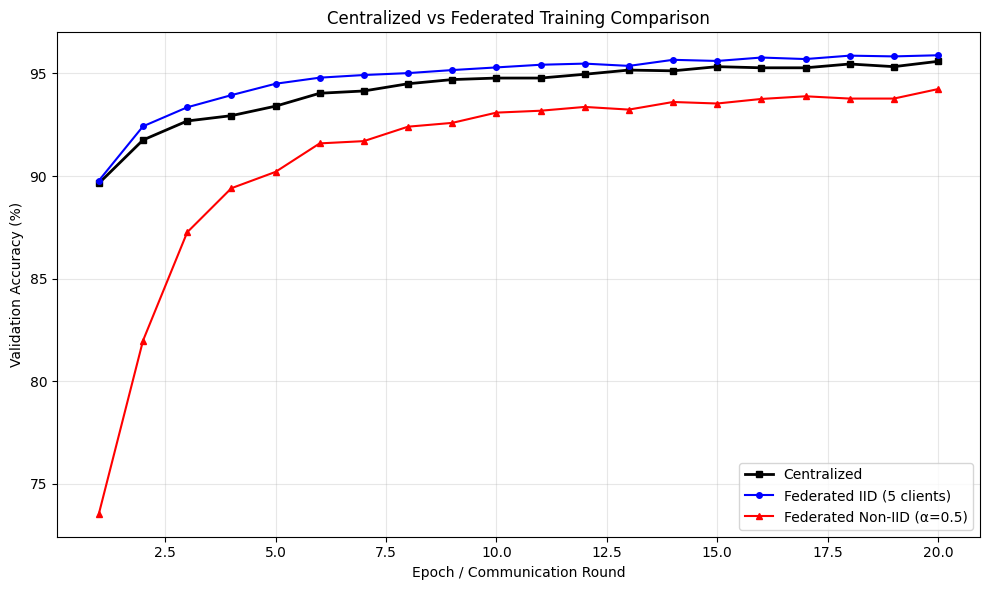

In [56]:
# ── Comparison Plot ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))

# Centralized
epochs = range(1, len(centralized_history["val_acc"]) + 1)
plt.plot(epochs, centralized_history["val_acc"], "k-s", markersize=4,
         label="Centralized", linewidth=2)

# Federated IID
rounds = range(1, len(fed_iid_history["global_val_acc"]) + 1)
plt.plot(rounds, fed_iid_history["global_val_acc"], "b-o", markersize=4,
         label="Federated IID (5 clients)")

# Federated Non-IID
rounds = range(1, len(fed_noniid_history["global_val_acc"]) + 1)
plt.plot(rounds, fed_noniid_history["global_val_acc"], "r-^", markersize=4,
         label="Federated Non-IID (\u03b1=0.5)")

plt.xlabel("Epoch / Communication Round")
plt.ylabel("Validation Accuracy (%)")
plt.title("Centralized vs Federated Training Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# ── Comparison Table ──────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"{'Method':<35} {'Best Val Acc':<15} {'Final Val Acc':<15} {'Rounds':<10}")
print(f"{'-'*70}")

best_c = max(centralized_history["val_acc"])
final_c = centralized_history["val_acc"][-1]
print(f"{'Centralized':<35} {best_c:<15.2f} {final_c:<15.2f} {len(centralized_history['val_acc']):<10}")

best_iid = max(fed_iid_history["global_val_acc"])
final_iid = fed_iid_history["global_val_acc"][-1]
print(f"{'Federated IID (5 clients)':<35} {best_iid:<15.2f} {final_iid:<15.2f} {len(fed_iid_history['global_val_acc']):<10}")

best_noniid = max(fed_noniid_history["global_val_acc"])
final_noniid = fed_noniid_history["global_val_acc"][-1]
print(f"{'Federated Non-IID (\u03b1=0.5)':<35} {best_noniid:<15.2f} {final_noniid:<15.2f} {len(fed_noniid_history['global_val_acc']):<10}")
print(f"{'='*70}")


COMPARISON SUMMARY
Method                              Best Val Acc    Final Val Acc   Rounds    
----------------------------------------------------------------------
Centralized                         95.59           95.59           20        
Federated IID (5 clients)           95.89           95.89           20        
Federated Non-IID (α=0.5)           94.24           94.24           20        


## 8. Communication Cost Analysis

In [58]:
def print_communication_cost(history, label=""):
    cfg = history.get("config", {})
    num_clients = cfg.get("num_clients", 5)
    num_rounds = cfg.get("num_rounds", 20)

    # FC layer: 2048*10 weights + 10 biases = 20,490 float32 params
    fc_params = 2048 * 10 + 10  # 20,490
    fc_size_kb = fc_params * 4 / 1024  # float32 = 4 bytes

    per_round_kb = num_clients * fc_size_kb * 2  # download + upload
    total_kb = per_round_kb * num_rounds
    total_mb = total_kb / 1024

    print(f"\n{'='*50}")
    if label:
        print(f"COMMUNICATION COST \u2014 {label}")
    else:
        print("COMMUNICATION COST ANALYSIS")
    print(f"{'='*50}")
    print(f"FC layer size      : {fc_params:,} params ({fc_size_kb:.1f} KB)")
    print(f"Per round          : {num_clients} clients \u00d7 {fc_size_kb:.1f} KB \u00d7 2 = {per_round_kb:.1f} KB")
    print(f"Total ({num_rounds} rounds) : {total_mb:.2f} MB")
    print(f"{'='*50}")

print_communication_cost(fed_iid_history, "Federated IID")
print_communication_cost(fed_noniid_history, "Federated Non-IID")


COMMUNICATION COST — Federated IID
FC layer size      : 20,490 params (80.0 KB)
Per round          : 5 clients × 80.0 KB × 2 = 800.4 KB
Total (20 rounds) : 15.63 MB

COMMUNICATION COST — Federated Non-IID
FC layer size      : 20,490 params (80.0 KB)
Per round          : 5 clients × 80.0 KB × 2 = 800.4 KB
Total (20 rounds) : 15.63 MB


## 9. Save Model

In [59]:
# Reconstruct full ResNet-50 with trained FC head for saving
full_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in full_model.parameters():
    param.requires_grad = False
full_model.fc = nn.Linear(2048, NUM_CLASSES)
full_model.fc.weight.data.copy_(fed_iid_server.model.fc.weight.data.cpu())
full_model.fc.bias.data.copy_(fed_iid_server.model.fc.bias.data.cpu())

SAVE_PATH = "resnet50_eurosat_federated.pth"
torch.save({
    'model_state_dict': full_model.state_dict(),
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'fed_iid_history': fed_iid_history,
    'fed_noniid_history': fed_noniid_history,
    'centralized_history': centralized_history,
}, SAVE_PATH)
print(f"Federated global model saved to {SAVE_PATH}")
del full_model

Federated global model saved to resnet50_eurosat_federated.pth
